In [1]:
import math
import pandas as pd 
import numpy as np 
import plotly.express


In [ ]:
df = pd.read_csv("age_vs_tvhours.csv")
df

,age,tvhours
0,18,0
1,18,1
2,18,1
3,18,1
4,18,1
...,...,...
1543,89,6
1544,89,6
1545,89,7
1546,89,8


In [10]:
fig = plotly.express.scatter(
    df,
    x="age",
    y="tvhours",
    opacity=0.5,
    title="TV Hours vs Age"
)


# approximate best-fit line
m, b = np.polyfit(df["age"], df["tvhours"], 1)
x_vals = np.array([df["age"].min(), df["age"].max()])
y_vals = m * x_vals + b

fig.add_scatter(
    x=x_vals,
    y=y_vals,
    mode="lines",
    name="Approx. line",
    line=dict(color="red", width=2)
)

fig.update_layout(
    xaxis_title="Age",
    yaxis_title="TV Hours",
    xaxis_title_font=dict(size=20),
    yaxis_title_font=dict(size=20),
    title_font=dict(size=30)
)
fig.show()

In [13]:
df2=pd.read_csv("excel_assessement1.csv")
df2

,Age,30s,40s,50s,60s,70s,80s
0,Slightly acceptable,1,5,6,5,5,2
1,Moderately acceptable,1,13,9,17,13,2
2,Highly acceptable,7,36,31,48,32,6
3,Slightly acceptable,11%,9%,13%,7%,10%,20%
4,Moderately acceptable,11%,24%,20%,24%,26%,20%
5,Highly acceptable,78%,67%,67%,69%,64%,60%


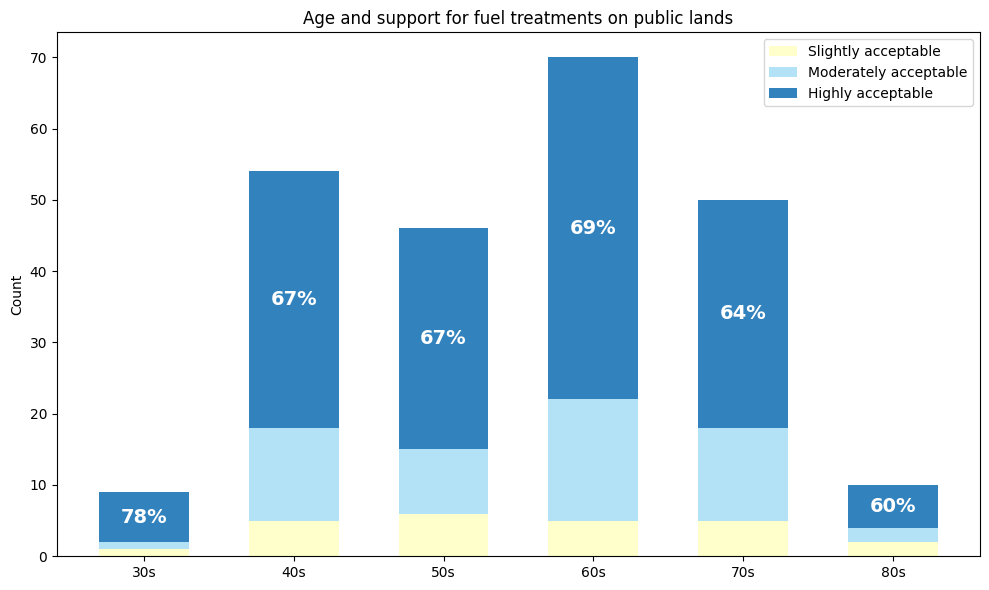

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Example structure for df2:
# df2 = pd.DataFrame({
#     'Age': ['30s', '40s', '50s', '60s', '70s', '80s'],
#     'Slightly acceptable': [...],
#     'Moderately acceptable': [...],
#     'Highly acceptable': [...]
# })

age_groups = df2['Age']
df2 = pd.DataFrame({
    'Age': df2.columns[1:],
    'Slightly acceptable': pd.to_numeric(df2.iloc[0, 1:].astype(str).str.replace('%', '', regex=False)),
    'Moderately acceptable': pd.to_numeric(df2.iloc[1, 1:].astype(str).str.replace('%', '', regex=False)),
    'Highly acceptable': pd.to_numeric(df2.iloc[2, 1:].astype(str).str.replace('%', '', regex=False)),
})

age_groups = df2['Age']
slightly = df2['Slightly acceptable']
moderately = df2['Moderately acceptable']
highly = df2['Highly acceptable']

bar_width = 0.6
ind = np.arange(len(age_groups))

plt.figure(figsize=(10,6))

p1 = plt.bar(ind, slightly, bar_width, label='Slightly acceptable', color='#ffffcc')
p2 = plt.bar(ind, moderately, bar_width, bottom=slightly, label='Moderately acceptable', color='#b3e2f7')
p3 = plt.bar(ind, highly, bar_width, bottom=slightly+moderately, label='Highly acceptable', color='#3182bd')

# Add percentage labels for "Highly acceptable"
for i, (x, h) in enumerate(zip(ind, highly)):
    total = slightly.iloc[i] + moderately.iloc[i] + highly.iloc[i]
    percent = int(round(100 * highly.iloc[i] / total))
    plt.text(x, slightly.iloc[i] + moderately.iloc[i] + highly.iloc[i]/2, f'{percent}%', 
             ha='center', va='center', color='white', fontsize=14, fontweight='bold')

plt.xticks(ind, age_groups)
plt.ylabel('Count')
plt.title('Age and support for fuel treatments on public lands')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import plotly.express as px
import pandas as pd

# Assuming df2 has columns: 'Age', 'Slightly acceptable', 'Moderately acceptable', 'Highly acceptable'
df_long = df2.melt(id_vars='Age', 
                   value_vars=['Slightly acceptable', 'Moderately acceptable', 'Highly acceptable'],
                   var_name='Acceptance', value_name='Count')

fig = px.bar(
    df_long, 
    x='Age', 
    y='Count', 
    color='Acceptance', 
    color_discrete_map={
        'Slightly acceptable': '#ffffcc',
        'Moderately acceptable': '#b3e2f7',
        'Highly acceptable': '#3182bd'
    },
    title='Age and support for fuel treatments on public lands',
    labels={'Count': 'Count'}
)

# Add percentage labels for "Highly acceptable"
for i, age in enumerate(df2['Age']):
    total = df2.iloc[i][['Slightly acceptable', 'Moderately acceptable', 'Highly acceptable']].sum()
    percent = int(round(100 * df2.iloc[i]['Highly acceptable'] / total))
    fig.add_annotation(
        x=age,
        y=df2.iloc[i]['Slightly acceptable'] + df2.iloc[i]['Moderately acceptable'] + df2.iloc[i]['Highly acceptable'] / 2,
        text=f"{percent}%",
        showarrow=False,
        font=dict(color="white", size=10, family="Arial Black"),
    )

fig.update_layout(barmode='stack')
fig.show()